In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [ ]:
from google.colab import files

files.upload()

Saving frame_04_06_0116.png to frame_04_06_0116.png


{'frame_04_06_0116.png': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x02\x80\x00\x00\x00\xf0\x08\x00\x00\x00\x00\xb5\x1b\x8a\x17\x00\x00 \x00IDATx\x01,\xc1\x01b\x00Ir\xc4F \x87+\xf9\xff\xcf\xf5\xb1\x0b\xe6\x9e\x1c\xe1\xff\x86\xd9\x0e=\x0cao\xc5~?\xb9\x16\xb0\xe7\x82\xd8aH\xca\xa1\x04\xc9\x8d\x16\xb4\x03\xc4H9I\xc2\xec\x8b\xccL\xd2\x82\xef\t\xde\xda\xef\x0em\xaf\x9f\xc7W\xb6[\x91\x8d\x84<v\x1a$y\x92R\x03\x12\xed\x9f\xe4\xf7\xbb\xef\xb1\x84\x94j\x9c\xab\xfc\xde\x8e\xfb9\xf6\x18\x11\xf0=\t\x03\xb3\x16p?\xef;\xe1F_\x9c\xdd\xd0N\xfe5\x0e\x0c\x02\xd3\xb7 \x91\xe8\xbbu?\x977\xea;\xee\xeb\rOl\x01\x81\xe7w\xadZI\xec\x8c\\\x1c\x0b\xc3\xc03\xe4P\x89F\x06\xe1})\xfdt?\xbd\x9f#\x0e\x84\x1d\xcd\x87\x80\x9c\x19\x92g\xa2\xef\xa3v\x06\xf24\xc7\xc1\x8d\xff:\x91ha\xcf%X\x96\x92\xb7\x9ag\x0bJ\xc1\xa7\'\x8b\x90Sj!\x8d\xb703\xa1\xd3\xd1\xb9_\xc5c\x91\x19\xdf\xf9\xcf\xe0\xc6\x9fv\xe0-\xc3\x1ay;m\xd7\xc0\x80\x13w\x84\xa4\xa7\x91d\xe3O\x90\xc4\xea\xe7W9\x96\'\xac\x00\xe1\x94\xb0\x95\x10+\x93[0\x0e$\x16\x99\xd

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d gti-upm/leapgestrecog
!unzip leapgestrecog.zip

Streaming output truncated to the last 5000 lines.
  inflating: leapgestrecog/leapGestRecog/07/06_index/frame_07_06_0001.png  
  inflating: leapgestrecog/leapGestRecog/07/06_index/frame_07_06_0002.png  
  inflating: leapgestrecog/leapGestRecog/07/06_index/frame_07_06_0003.png  
  inflating: leapgestrecog/leapGestRecog/07/06_index/frame_07_06_0004.png  
  inflating: leapgestrecog/leapGestRecog/07/06_index/frame_07_06_0005.png  
  inflating: leapgestrecog/leapGestRecog/07/06_index/frame_07_06_0006.png  
  inflating: leapgestrecog/leapGestRecog/07/06_index/frame_07_06_0007.png  
  inflating: leapgestrecog/leapGestRecog/07/06_index/frame_07_06_0008.png  
  inflating: leapgestrecog/leapGestRecog/07/06_index/frame_07_06_0009.png  
  inflating: leapgestrecog/leapGestRecog/07/06_index/frame_07_06_0010.png  
  inflating: leapgestrecog/leapGestRecog/07/06_index/frame_07_06_0011.png  
  inflating: leapgestrecog/leapGestRecog/07/06_index/frame_07_06_0012.png  
  inflating: leapgestrecog/leapGestRe

In [ ]:
dataset_path = "/content/leapGestRecog"

images = []
labels = []
class_names = []

for person in os.listdir(dataset_path):
    person_path = os.path.join(dataset_path, person)

    if os.path.isdir(person_path):
        for gesture in os.listdir(person_path):

            gesture_path = os.path.join(person_path, gesture)

            if gesture not in class_names:
                class_names.append(gesture)

            label = class_names.index(gesture)

            for img in os.listdir(gesture_path):

                img_path = os.path.join(gesture_path, img)

                image = cv2.imread(img_path)

                image = cv2.resize(image, (64,64))

                images.append(image)

                labels.append(label)

In [ ]:
X = np.array(images, dtype="float32") / 255.0

y = np.array(labels)

y = to_categorical(y)

print("Images Shape :", X.shape)
print("Labels Shape :", y.shape)

Images Shape : (20000, 64, 64, 3)
Labels Shape : (20000, 10)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(16000, 64, 64, 3)
(4000, 64, 64, 3)


In [ ]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(64,64,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(len(class_names),activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,626,442 (6.20 MB)

 Trainable params: 1,626,442 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 52s 128ms/step - accuracy: 0.8502 - loss: 0.4681 - val_accuracy: 0.9975 - val_loss: 0.0134
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 52s 129ms/step - accuracy: 0.9835 - loss: 0.0549 - val_accuracy: 0.9987 - val_loss: 0.0045
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 51s 129ms/step - accuracy: 0.9876 - loss: 0.0380 - val_accuracy: 1.0000 - val_loss: 7.7002e-04
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 83s 131ms/step - accuracy: 0.9926 - loss: 0.0254 - val_accuracy: 1.0000 - val_loss: 4.2383e-04
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 83s 132ms/step - accuracy: 0.9906 - loss: 0.0275 - val_accuracy: 0.9994 - val_loss: 0.0014
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 52s 129ms/step - accuracy: 0.9937 - loss: 0.0190 - val_accuracy: 1.0000 - val_loss: 5.7935e-04
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 53s 131ms/step - accuracy: 0.9940 - loss: 0.0170 - val_accuracy: 1.0000 - val_loss: 2.6539e-04
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 52s 130ms/step - accuracy: 

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy :", accuracy*100)

125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9987 - loss: 0.0059
Test Accuracy : 99.87499713897705


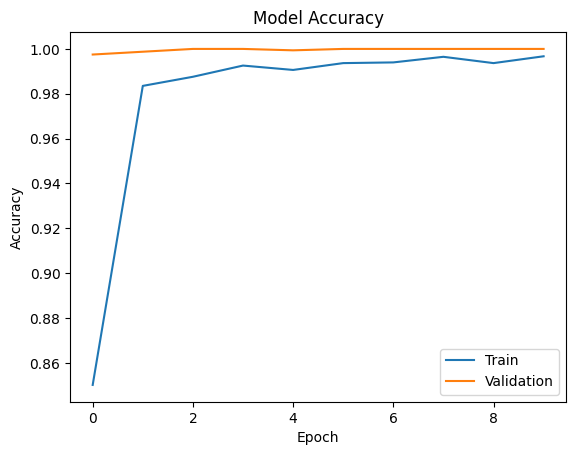

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

In [ ]:
model.save("hand_gesture_model.h5")

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
image = cv2.imread("/content/leapGestRecog/00/01_palm/frame_00_01_0001.png")

image = cv2.resize(image,(64,64))

image = image/255.0

image = np.expand_dims(image,axis=0)

prediction = model.predict(image)

predicted_class = np.argmax(prediction)

print("Predicted Gesture :", class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Predicted Gesture : 01_palm
